In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [3]:
# Loading Student Performence Dataset
df = pd.read_csv("C:/Users/Admin/Machine Learning Algorithms/Datasets/Student_Performance.csv")

In [4]:
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [5]:
# Features & Target

X = df.drop(columns=["final_grade", "student_id"])
y = df["final_grade"]

In [6]:
#  Separate categorical & numeric columns

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

C:\Users\Admin\AppData\Local\Temp\ipykernel_22828\3406892963.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns


In [ ]:
# Preprocessing
# Random Forest doesn't need scaling
# Only categorical needs encoding
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

In [ ]:
# Random Forest Model (Hyperparameters)
# ----------------------------
rf_model = RandomForestClassifier(
    n_estimators=200,        # number of trees
    random_state=42,
    max_depth=12,            # controls overfitting
    min_samples_split=10,    # avoid too many small splits
    min_samples_leaf=5,      # avoids tiny leaf nodes
    class_weight="balanced", # handles imbalance in grades
    n_jobs=-1                # uses all CPU cores (fast)
)

In [11]:
#  Pipeline
# ----------------------------
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", rf_model)
])

In [12]:
# Train-Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
#  Train
# ----------------------------
pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [14]:
#Predict
y_pred = pipeline.predict(X_test)

In [15]:
y_pred

array(['b', 'f', 'c', ..., 'f', 'd', 'd'], shape=(5000,), dtype=object)

In [16]:
#  Evaluation
# ----------------------------
print("\n===== Random Forest Classifier =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


===== Random Forest Classifier =====
Accuracy: 0.997

Confusion Matrix:
 [[ 241    0    0    0    0    0]
 [   1  538    0    0    0    0]
 [   0    1 1231    0    0    0]
 [   0    0    3 1255    4    0]
 [   0    0    0    1 1129    5]
 [   0    0    0    0    0  591]]

Classification Report:
               precision    recall  f1-score   support

           a       1.00      1.00      1.00       241
           b       1.00      1.00      1.00       539
           c       1.00      1.00      1.00      1232
           d       1.00      0.99      1.00      1262
           e       1.00      0.99      1.00      1135
           f       0.99      1.00      1.00       591

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



<Figure size 700x600 with 0 Axes>

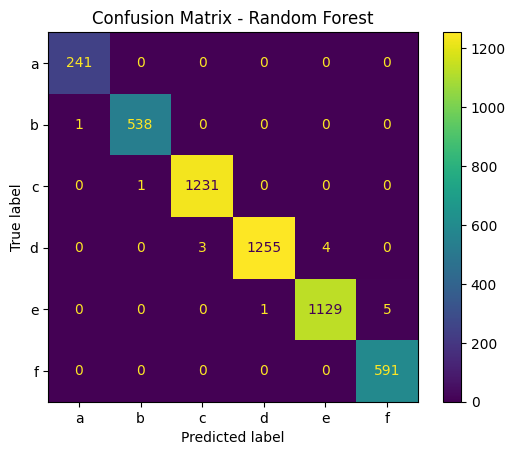

In [17]:
# Confusion Matrix Plot
# ----------------------------
plt.figure(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - Random Forest")
plt.show()

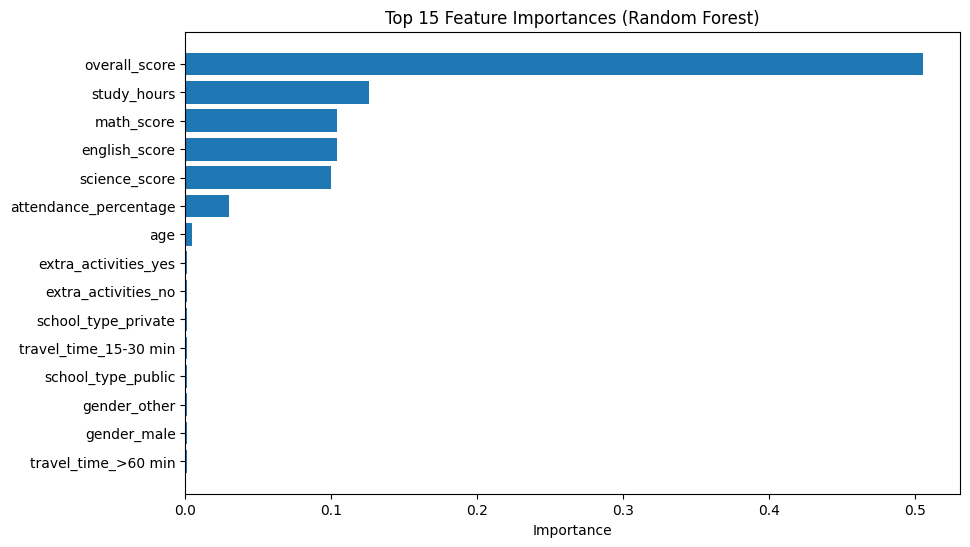

In [20]:
# if you want to find the feature importance


# Get trained model
rf_trained = pipeline.named_steps["model"]

# Get feature names after preprocessing
ohe = pipeline.named_steps["preprocess"].named_transformers_["cat"]
cat_features = ohe.get_feature_names_out(categorical_cols)
all_features = list(cat_features) + list(numeric_cols)

importances = rf_trained.feature_importances_

# Top 15
indices = np.argsort(importances)[-15:]

plt.figure(figsize=(10, 6))
plt.barh(np.array(all_features)[indices], importances[indices])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.show()
